# Persona Generation Testing

This notebook tests:
1. Persona generation with realistic distributions
2. Demographic quota adherence
3. Screening rule application
4. Distribution visualization

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.persona.generator import PersonaGenerator

import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_palette("husl")
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Generate Test Sample

In [2]:
# Initialize generator
persona_gen = PersonaGenerator(random_seed=42)

# Generate sample
n_personas = 200
print(f"Generating {n_personas} personas...")
personas = persona_gen.generate_batch(n_personas, apply_screening=True)

print(f"✓ Generated {len(personas)} personas")

Generating 200 personas...
✓ Generated 200 personas


## 2. Convert to DataFrame for Analysis

In [3]:
# Convert to DataFrame
data = []
for p in personas:
    row = {
        'id': p.id,
        **p.demographics,
        **p.psychographics
    }
    data.append(row)

df = pd.DataFrame(data)
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (200, 9)


,id,gender,age,occupation,age_band,category_buyer,sc_players,inertia,target_group
0,P00001,Female,26,Finance,18-35,"[Lottery played in-store/person, Paper scratch...",SC Players,5,Young non-rejectors 18-35
1,P00002,Male,18,Government,18-35,[None of the above],SC Non-players,4,Other
2,P00003,Female,26,Unemployed,18-35,[Paper scratchcards bought in person],SC Players,5,Young non-rejectors 18-35
3,P00004,Male,28,Healthcare,18-35,[None of the above],SC Players,6,Other
4,P00005,Female,37,Student,36-55,[Lottery played online/app],SC Players,4,Other


## 3. Demographic Distributions

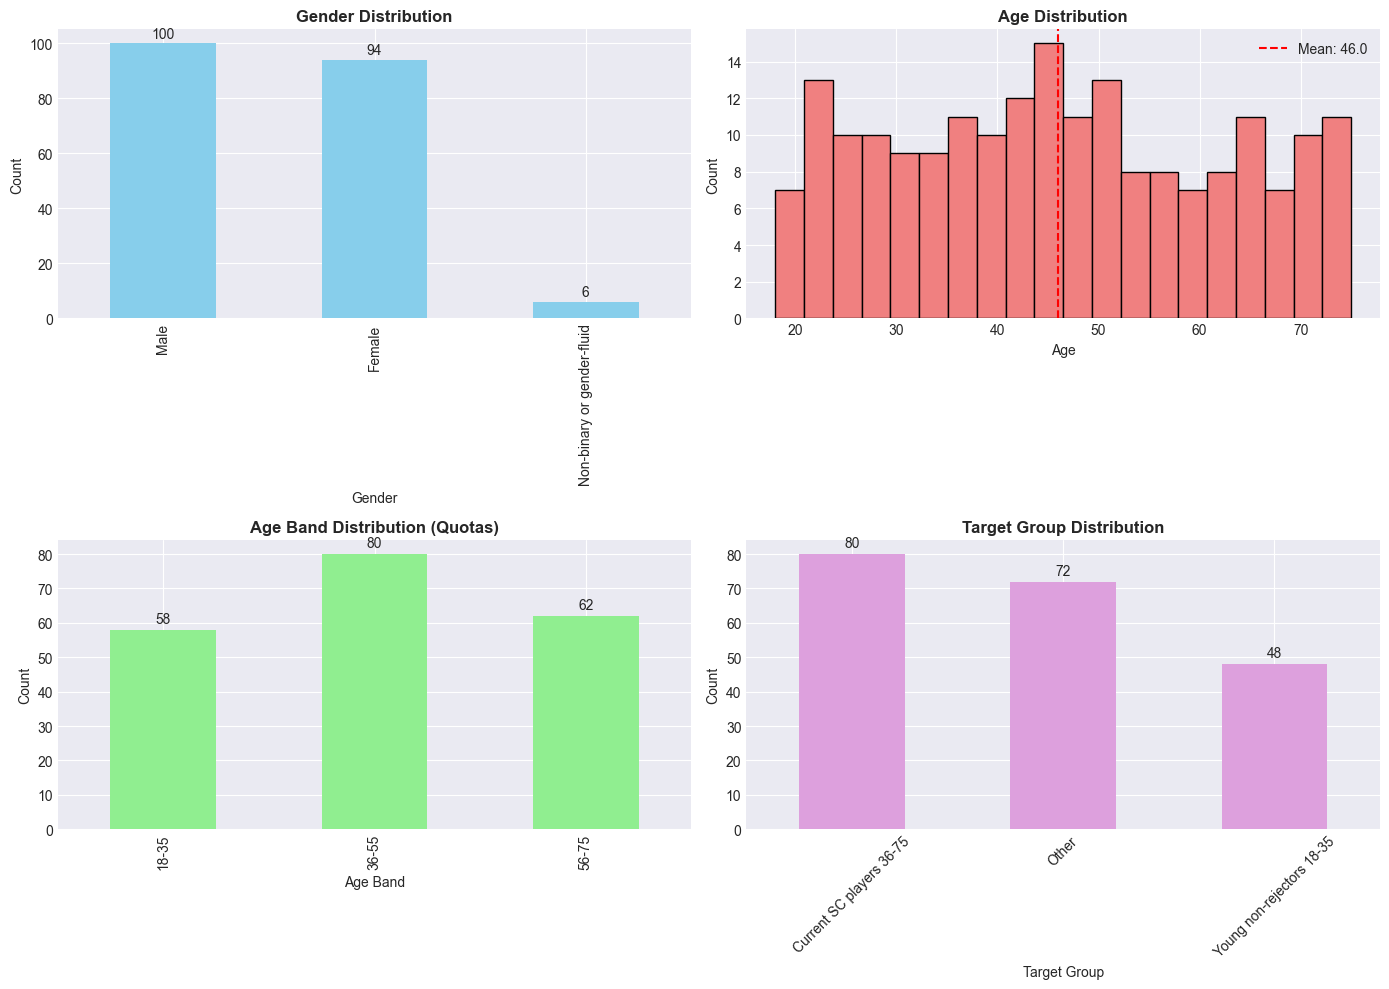

In [4]:
# Gender distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gender
ax = axes[0, 0]
gender_counts = df['gender'].value_counts()
gender_counts.plot(kind='bar', ax=ax, color='skyblue')
ax.set_title('Gender Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Gender')
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 2, str(v), ha='center')

# Age distribution
ax = axes[0, 1]
df['age'].hist(bins=20, ax=ax, color='lightcoral', edgecolor='black')
ax.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
ax.legend()

# Age bands
ax = axes[1, 0]
age_band_counts = df['age_band'].value_counts().sort_index()
age_band_counts.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title('Age Band Distribution (Quotas)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Age Band')
for i, v in enumerate(age_band_counts.values):
    ax.text(i, v + 2, str(v), ha='center')

# Target group
ax = axes[1, 1]
target_counts = df['target_group'].value_counts()
target_counts.plot(kind='bar', ax=ax, color='plum')
ax.set_title('Target Group Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Target Group')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.show()

## 4. Psychographic Distributions

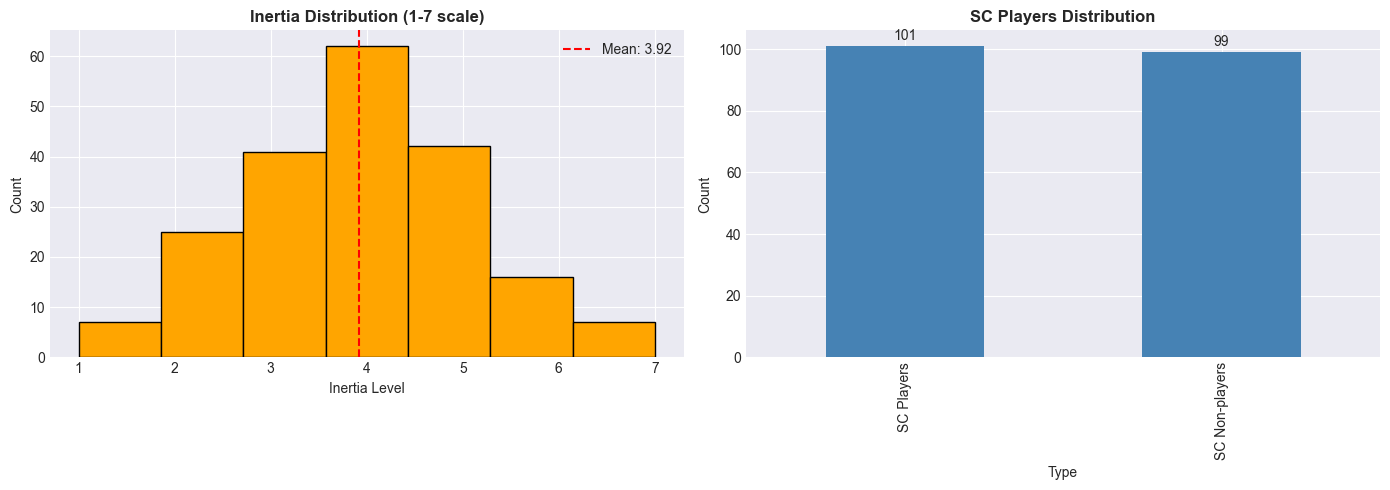

In [5]:
# Inertia distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia histogram
ax = axes[0]
df['inertia'].hist(bins=7, ax=ax, color='orange', edgecolor='black')
ax.set_title('Inertia Distribution (1-7 scale)', fontsize=12, fontweight='bold')
ax.set_xlabel('Inertia Level')
ax.set_ylabel('Count')
ax.axvline(df['inertia'].mean(), color='red', linestyle='--', label=f"Mean: {df['inertia'].mean():.2f}")
ax.legend()

# SC Players
ax = axes[1]
sc_counts = df['sc_players'].value_counts()
sc_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('SC Players Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Type')
for i, v in enumerate(sc_counts.values):
    ax.text(i, v + 2, str(v), ha='center')

plt.tight_layout()
plt.show()

## 5. Category Buyer Analysis

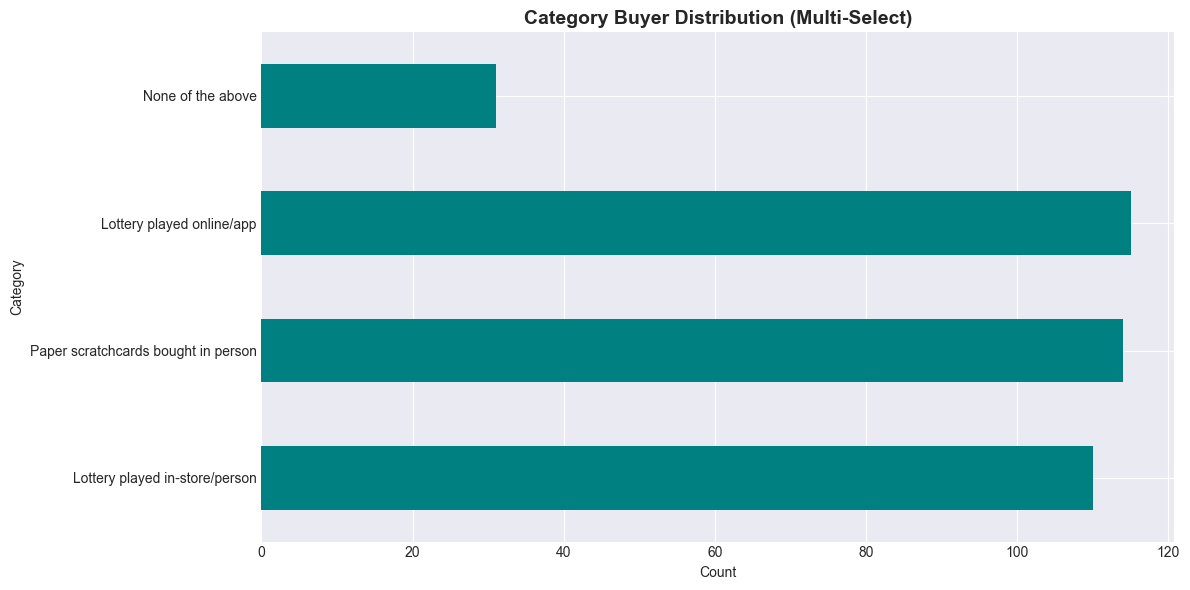


Category Buyer Counts:
   Lottery played online/app: 115
   Paper scratchcards bought in person: 114
   Lottery played in-store/person: 110
   None of the above: 31


In [6]:
# Flatten category buyer lists
all_categories = []
for buyers in df['category_buyer']:
    if isinstance(buyers, list):
        all_categories.extend(buyers)
    else:
        all_categories.append(str(buyers))

# Count occurrences
from collections import Counter
category_counts = Counter(all_categories)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
pd.Series(category_counts).plot(kind='barh', ax=ax, color='teal')
ax.set_title('Category Buyer Distribution (Multi-Select)', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

print("\nCategory Buyer Counts:")
for cat, count in category_counts.most_common():
    print(f"   {cat}: {count}")

## 6. Quota Validation

In [7]:
# Check quota distributions
print("Quota Validation")
print("=" * 80)

# Gender quota (should be ~50/50)
print("\nGender Distribution:")
gender_pct = df['gender'].value_counts(normalize=True) * 100
for gender, pct in gender_pct.items():
    print(f"   {gender}: {pct:.1f}%")

# Age band quota (should be ~33% each)
print("\nAge Band Distribution:")
age_band_pct = df['age_band'].value_counts(normalize=True).sort_index() * 100
for band, pct in age_band_pct.items():
    print(f"   {band}: {pct:.1f}%")
    
# Target group
print("\nTarget Group Distribution:")
target_pct = df['target_group'].value_counts(normalize=True) * 100
for group, pct in target_pct.items():
    print(f"   {group}: {pct:.1f}%")

Quota Validation

Gender Distribution:
   Male: 50.0%
   Female: 47.0%
   Non-binary or gender-fluid: 3.0%

Age Band Distribution:
   18-35: 29.0%
   36-55: 40.0%
   56-75: 31.0%

Target Group Distribution:
   Current SC players 36-75: 40.0%
   Other: 36.0%
   Young non-rejectors 18-35: 24.0%


## 7. Screening Validation

In [8]:
# Check for screened occupations
screened_occupations = [
    'Advertising/PR',
    'Marketing/Market Research',
    'Lottery sales/distribution',
    'Tobacco shop salesperson'
]

print("Screening Validation")
print("=" * 80)

# Check occupations
screened_found = df[df['occupation'].isin(screened_occupations)]
print(f"\nScreened occupations found: {len(screened_found)}")
if len(screened_found) > 0:
    print("⚠️  WARNING: Found personas with screened occupations!")
    print(screened_found[['id', 'occupation']])
else:
    print("✓ No screened occupations found (correct)")

# Check age range
out_of_range = df[(df['age'] < 18) | (df['age'] > 75)]
print(f"\nAges out of range (18-75): {len(out_of_range)}")
if len(out_of_range) > 0:
    print("⚠️  WARNING: Found personas with out-of-range ages!")
    print(out_of_range[['id', 'age']])
else:
    print("✓ All ages in valid range (correct)")

Screening Validation

Screened occupations found: 0
✓ No screened occupations found (correct)

Ages out of range (18-75): 0
✓ All ages in valid range (correct)


## 8. Sample Persona Descriptions

In [9]:
# Show sample persona descriptions (for LLM prompts)
print("Sample Persona Descriptions for LLM:")
print("=" * 80)

for i in range(min(10, len(personas))):
    print(f"\n{i+1}. {personas[i].to_description()}")

Sample Persona Descriptions for LLM:

1. 26 years old, female, works in Finance, buys lottery played in-store/person, paper scratchcards bought in person, lottery played online/app, likes to try new and different products

2. 18 years old, male, works in Government, buys none of the above

3. 26 years old, female, works in Unemployed, buys paper scratchcards bought in person, likes to try new and different products

4. 28 years old, male, works in Healthcare, buys none of the above, likes to try new and different products

5. 37 years old, female, works in Student, buys lottery played online/app

6. 47 years old, male, works in Other, buys none of the above

7. 58 years old, female, works in Finance, buys lottery played online/app, paper scratchcards bought in person, likes to try new and different products

8. 42 years old, male, works in Retired, buys paper scratchcards bought in person, lottery played in-store/person, lottery played online/app, likes to try new and different product

## Summary

Persona generation has been validated:

✅ **Demographics** - Realistic distributions across gender, age, occupation

✅ **Quotas** - Age bands and gender quotas are balanced

✅ **Psychographics** - Inertia follows normal distribution, category buyers vary

✅ **Screening** - No screened occupations or out-of-range ages

✅ **Descriptions** - Natural language persona descriptions ready for LLM conditioning

**Next Steps:**
- Move to notebook 04 to test single question responses
- Adjust distributions if needed to better match ground truth